# 10-year CVD death model v1 — NHANES 1999–2008 + Linked Mortality (follow-up to 2019)

A **prospective** model: each adult was examined once (1999–2008) and followed through the
National Death Index until 31 December 2019. The outcome is **death from heart disease or stroke
within 10 years** of the exam. Unlike the cross-sectional model (`cvd_nhanes_v2.ipynb`), inputs
are measured *before* the outcome, so the model can learn that higher BP, cholesterol, smoking and
so on raise future risk.

* Every survivor has ≥ 130 months of follow-up, so the 10-year outcome is fully observed.
* People who already reported CVD at the exam are excluded (primary prevention, like PREVENT).
* Deaths from other causes within 10 years count as "no CVD death" (no competing-risk model).
* Survey weights are not applied: results describe this sample, not US population estimates.

Rules: stratified 80 / 20 split; the test set is used once (sections 7–10); model choice,
calibration and thresholds come from 5-fold cross-validation on the training set only.
Feature code is shared with the API (`Back-End/ml/nhanes.py`), and every cycle is harmonised onto
the same raw columns the app sends (`Back-End/ml/nhanes_mortality.py`).

In [1]:
import json, os, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
BACKEND = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
sys.path.insert(0, str(BACKEND))
from ml._native import import_lightgbm
from ml import prevent
from ml.nhanes import (FEATURE_COLUMNS, FEATURE_LABELS, LABELS, MEDICATION_COLUMNS, RAW_CODED_COLUMNS,
                       RAW_COLUMNS, RAW_NUMERIC_COLUMNS, build_pipeline, model_coefficients)
from ml.nhanes_mortality import build_dataset

lgb = import_lightgbm()
SEED = 42
AGE_MAX = 85  # NHANES 1999-2006 top-codes age at 85 (80 in 2007-2008)
# Fixed clinical bands for 10-year CVD death, as in the ESC SCORE system: <1% low, 1-<5% moderate, >=5% high.
BANDS = {"low_max": 0.01, "medium_max": 0.05}
OUT_DIR = BACKEND / "model" / "mortality"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE = Path(os.environ.get("NHANES_CACHE", BACKEND / "model" / "nhanes_cache"))
# Not measured in 1999-2008 (hs-CRP, sleep, sedentary time) or not separable (Asian before 2011).
UNAVAILABLE = {"log_crp", "sleep_weekday", "sleep_weekend", "sedentary_min", "race_asian"}
COLUMNS = [c for c in FEATURE_COLUMNS if c not in UNAVAILABLE] + MEDICATION_COLUMNS
np.random.seed(SEED)
print("sklearn", sklearn.__version__, "| features:", len(COLUMNS))

sklearn 1.6.1 | features: 37


Medication inputs are **included** here: in a prospective model, treatment at the exam is a
legitimate predictor of what happens later (PREVENT uses the same two inputs).

## 1. Build the dataset

In [2]:
data = build_dataset(CACHE)  # downloads NHANES tables and NCHS mortality files on first run
data.to_csv(OUT_DIR / "nhanes_mortality_1999_2008.csv", index=False)
X, y = data[RAW_COLUMNS], data["CVD_DEATH_10Y"].to_numpy()
print(f"{len(data)} adults without CVD at the exam; {y.sum()} CVD deaths within 10 years ({y.mean():.2%}); "
      f"{data.DIED_OTHER_10Y.sum()} other deaths")
print("minimum follow-up among survivors (months):", data.loc[data.MORTSTAT == 0, "PERMTH_EXM"].min())
age_groups = pd.cut(data.RIDAGEYR, [19, 29, 39, 49, 59, 69, 79, 85])
display(data.groupby(age_groups, observed=True).agg(adults=("SEQN", "size"), cvd_deaths=("CVD_DEATH_10Y", "sum"),
                                                    rate=("CVD_DEATH_10Y", "mean")).round(4))

19605 adults without CVD at the exam; 589 CVD deaths within 10 years (3.00%); 1499 other deaths
minimum follow-up among survivors (months): 130.0


,adults,cvd_deaths,rate
RIDAGEYR,,,
"(19, 29]",3967,4,0.0010
"(29, 39]",3711,10,0.0027
"(39, 49]",3548,32,0.0090
"(49, 59]",2694,38,0.0141
"(59, 69]",2789,93,0.0333
"(69, 79]",1846,161,0.0872
"(79, 85]",1050,251,0.2390


## 2. Train / test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print(f"train {len(y_train)} ({y_train.sum()} deaths) | test {len(y_test)} ({y_test.sum()} deaths)")

train 15684 (471 deaths) | test 3921 (118 deaths)


## 3. Model comparison (5-fold cross-validation on the training set)

In [4]:
def lr(c):
    return LogisticRegression(C=c, max_iter=5000, class_weight="balanced")

candidates = {
    "Logistic regression (C=0.01)": lr(0.01),
    "Logistic regression (C=0.1)": lr(0.1),
    "Logistic regression (C=1)": lr(1),
    "HistGradientBoosting": HistGradientBoostingClassifier(learning_rate=0.03, max_depth=3, max_iter=400,
                                                           l2_regularization=1.0, class_weight="balanced", random_state=SEED),
    "LightGBM": lgb.LGBMClassifier(n_estimators=600, learning_rate=0.01, num_leaves=4, min_child_samples=40, subsample=0.8,
                                   subsample_freq=1, colsample_bytree=0.6, reg_lambda=5, is_unbalance=True, verbosity=-1, random_state=SEED),
    "XGBoost": XGBClassifier(n_estimators=600, learning_rate=0.01, max_depth=2, subsample=0.8, colsample_bytree=0.6,
                             min_child_weight=5, reg_lambda=5, scale_pos_weight=30, eval_metric="logloss", n_jobs=-1,
                             random_state=SEED, verbosity=0),
}
rows, oof = [], {}
for name, model in candidates.items():
    fold_auc, pred = [], np.zeros(len(y_train))
    for tr, va in cv.split(X_train, y_train):
        fitted = build_pipeline(model, columns=COLUMNS, age_max=AGE_MAX).fit(X_train.iloc[tr], y_train[tr])
        pred[va] = fitted.predict_proba(X_train.iloc[va])[:, 1]
        fold_auc.append(roc_auc_score(y_train[va], pred[va]))
    oof[name] = pred
    rows.append({"model": name, "CV AUC (mean)": np.mean(fold_auc), "fold min": np.min(fold_auc),
                 "fold max": np.max(fold_auc), "CV PR-AUC": average_precision_score(y_train, pred)})
comparison = pd.DataFrame(rows).set_index("model").round(3)
display(comparison.sort_values("CV AUC (mean)", ascending=False))
best = comparison["CV AUC (mean)"].max()
chosen = next(n for n in candidates if comparison.loc[n, "CV AUC (mean)"] >= best - 0.005)
print("best CV AUC", best, "-> chosen (simplest within 0.005):", chosen)

,CV AUC (mean),fold min,fold max,CV PR-AUC
model,,,,
LightGBM,0.889,0.865,0.919,0.209
Logistic regression (C=0.01),0.888,0.861,0.914,0.202
XGBoost,0.888,0.864,0.916,0.208
HistGradientBoosting,0.886,0.865,0.913,0.205
Logistic regression (C=0.1),0.885,0.850,0.912,0.201
Logistic regression (C=1),0.882,0.839,0.912,0.200


best CV AUC 0.889 -> chosen (simplest within 0.005): Logistic regression (C=0.01)


## 4. Probability calibration (sigmoid, 5-fold, training set)

In [5]:
def calibrated():
    return CalibratedClassifierCV(candidates[chosen], method="sigmoid", cv=5)

oof_cal = cross_val_predict(build_pipeline(calibrated(), columns=COLUMNS, age_max=AGE_MAX), X_train, y_train,
                            cv=cv, method="predict_proba")[:, 1]
display(pd.DataFrame({
    "raw (class-weighted)": [roc_auc_score(y_train, oof[chosen]), brier_score_loss(y_train, oof[chosen]), oof[chosen].mean()],
    "calibrated": [roc_auc_score(y_train, oof_cal), brier_score_loss(y_train, oof_cal), oof_cal.mean()],
}, index=["CV AUC", "CV Brier", "mean predicted"]).round(4))
print(f"actual 10-year CVD death rate (train): {y_train.mean():.4f}")

,raw (class-weighted),calibrated
CV AUC,0.8876,0.8877
CV Brier,0.1319,0.0263
mean predicted,0.2618,0.0302


actual 10-year CVD death rate (train): 0.0300


## 5. Risk bands

Fixed clinical cut-offs for 10-year CVD death, as used by the ESC SCORE system: **low < 1 %,
medium 1–5 %, high ≥ 5 %**. Their operating points on out-of-fold training predictions:

In [6]:
def operating_point(y_true, scores, t):
    flagged = scores >= t
    tn, fp, fn, tp = confusion_matrix(y_true, flagged, labels=[0, 1]).ravel()
    return {"threshold": t, "sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
            "ppv": tp / (tp + fp) if tp + fp else float("nan"), "npv": tn / (tn + fn), "flagged share": flagged.mean()}

display(pd.DataFrame({"medium or high (>= 1%)": operating_point(y_train, oof_cal, BANDS["low_max"]),
                      "high (>= 5%)": operating_point(y_train, oof_cal, BANDS["medium_max"])}).round(3))

,medium or high (>= 1%),high (>= 5%)
threshold,0.010,0.050
sensitivity,0.960,0.749
specificity,0.549,0.859
ppv,0.062,0.141
npv,0.998,0.991
flagged share,0.467,0.159


## 6. Fit the final calibrated model on the whole training set

In [7]:
final = build_pipeline(calibrated(), columns=COLUMNS, age_max=AGE_MAX).fit(X_train, y_train)

## 7. One-time evaluation on the held-out test set

In [8]:
prob = final.predict_proba(X_test)[:, 1]
flag, high = operating_point(y_test, prob, BANDS["low_max"]), operating_point(y_test, prob, BANDS["medium_max"])
rng = np.random.default_rng(SEED)
pos, neg = np.where(y_test == 1)[0], np.where(y_test == 0)[0]
boot_idx = [np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]) for _ in range(1000)]
boot = [roc_auc_score(y_test[i], prob[i]) for i in boot_idx]
obs, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
bin_ids = np.digitize(prob, np.quantile(prob, np.linspace(0, 1, 11))[1:-1])
ece = float(sum(abs(prob[bin_ids == b].mean() - y_test[bin_ids == b].mean()) * (bin_ids == b).mean()
                for b in range(10) if (bin_ids == b).any()))
tn, fp, fn, tp = confusion_matrix(y_test, prob >= BANDS["low_max"], labels=[0, 1]).ravel()
metrics = {
    "model_name": "CVD 10-year Mortality Logistic",
    "model_version": "1.0.0",
    "algorithm": f"{chosen}, sigmoid-calibrated (5-fold)",
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "data": "NHANES 1999-2008 adults 20+ without CVD at exam, NCHS Linked Mortality Files (follow-up to 2019)",
    "label": "Death from heart disease or stroke within 10 years of the exam (UCOD_LEADING 1 or 5)",
    "score_meaning": "10-year probability of cardiovascular death",
    "n_train": int(len(y_train)), "n_test": int(len(y_test)), "prevalence": float(y.mean()),
    "age_range": [20, AGE_MAX],
    "threshold_rule": "fixed clinical bands for 10-year CVD death (ESC SCORE style): <1% low, 1-5% medium, >=5% high",
    "decision_threshold": BANDS["low_max"],
    "risk_bands": BANDS,
    "auc": float(roc_auc_score(y_test, prob)),
    "auc_ci95": [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))],
    "cv_auc": float(roc_auc_score(y_train, oof_cal)),
    "model_comparison_cv_auc": {k: float(v) for k, v in comparison["CV AUC (mean)"].items()},
    "pr_auc": float(average_precision_score(y_test, prob)),
    "sensitivity": float(flag["sensitivity"]), "recall": float(flag["sensitivity"]),
    "specificity": float(flag["specificity"]), "precision": float(flag["ppv"]), "ppv": float(flag["ppv"]),
    "npv": float(flag["npv"]), "balanced_accuracy": float((flag["sensitivity"] + flag["specificity"]) / 2),
    "accuracy": float((tp + tn) / len(y_test)), "f1": float(2 * tp / (2 * tp + fp + fn)),
    "flagged_share": float(flag["flagged share"]),
    "high_band": {k: float(high[k]) for k in ["sensitivity", "specificity", "ppv", "npv"]},
    "brier": float(brier_score_loss(y_test, prob)), "ece": ece,
    "mean_predicted": float(prob.mean()), "observed_rate": float(y_test.mean()),
    "calibration": [{"mean_predicted": float(p), "observed_rate": float(o)} for p, o in zip(mean_pred, obs)],
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    "note": ("Prospective: inputs measured before the outcome. Outcome is CVD death only (non-fatal heart "
             "attacks and strokes are not in the public linkage). Survey weights not applied."),
}
display(pd.DataFrame({"medium or high (>= 1%)": flag, "high (>= 5%)": high}).round(3))
display(pd.Series({k: metrics[k] for k in ["auc", "auc_ci95", "pr_auc", "brier", "ece", "mean_predicted", "observed_rate"]}))

,medium or high (>= 1%),high (>= 5%)
threshold,0.010,0.050
sensitivity,0.983,0.805
specificity,0.557,0.854
ppv,0.064,0.146
npv,0.999,0.993
flagged share,0.459,0.166


auc                                               0.909255
auc_ci95          [0.8853650329579236, 0.9298158902204772]
pr_auc                                            0.238786
brier                                             0.025589
ece                                               0.006781
mean_predicted                                    0.030191
observed_rate                                     0.030094
dtype: object

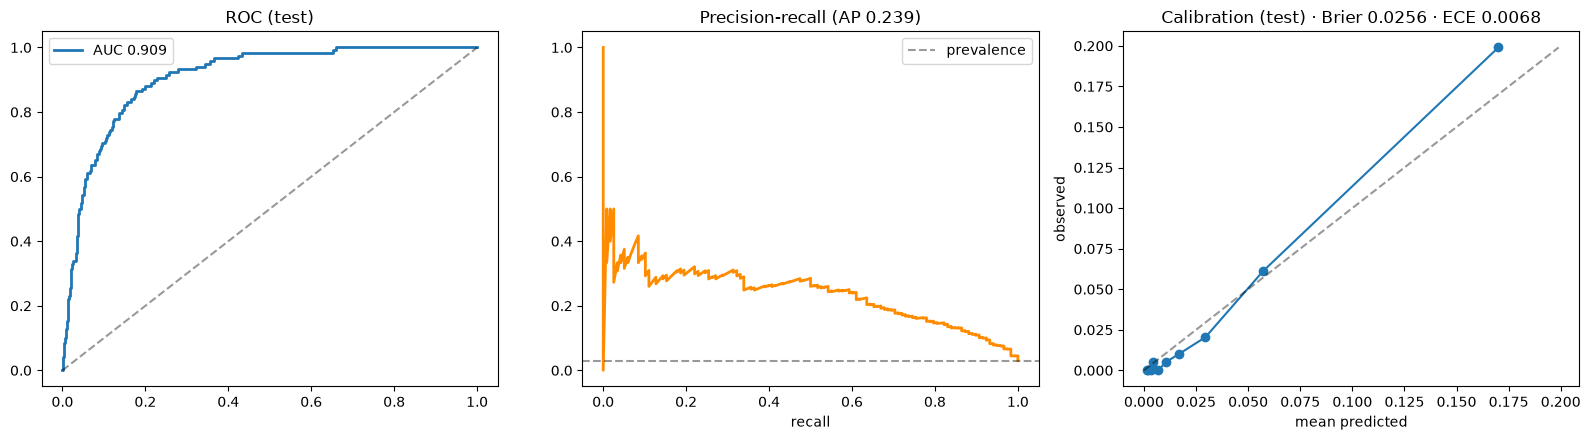

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
f, t, _ = roc_curve(y_test, prob)
ax[0].plot(f, t, lw=2, label=f"AUC {metrics['auc']:.3f}"); ax[0].plot([0, 1], [0, 1], "k--", alpha=.4); ax[0].set_title("ROC (test)"); ax[0].legend()
p, r, _ = precision_recall_curve(y_test, prob)
ax[1].plot(r, p, lw=2, color="darkorange"); ax[1].axhline(y_test.mean(), ls="--", c="k", alpha=.4, label="prevalence")
ax[1].set_title(f"Precision-recall (AP {metrics['pr_auc']:.3f})"); ax[1].set_xlabel("recall"); ax[1].legend()
lim = max(mean_pred.max(), obs.max())
ax[2].plot(mean_pred, obs, "o-"); ax[2].plot([0, lim], [0, lim], "k--", alpha=.4)
ax[2].set_title(f"Calibration (test) · Brier {metrics['brier']:.4f} · ECE {ece:.4f}"); ax[2].set_xlabel("mean predicted"); ax[2].set_ylabel("observed")
plt.tight_layout(); plt.savefig(OUT_DIR / "diagnostic.png", dpi=150); plt.show()

## 8. Head-to-head with AHA PREVENT (same test people)

PREVENT estimates 10-year *total* CVD (fatal and non-fatal), so here it is compared only on
ranking (AUC) against observed CVD deaths. It applies to ages 30–79 with in-range readings.

In [10]:
prevent_risk = np.array([r["risk"] if r["available"] else np.nan for r in (prevent.from_raw(row) for row in X_test.to_dict("records"))])
ok = ~np.isnan(prevent_risk)
diffs = []
for i in range(1000):
    idx = rng.choice(np.where(ok)[0], ok.sum())
    if y_test[idx].min() == y_test[idx].max():
        continue
    diffs.append(roc_auc_score(y_test[idx], prob[idx]) - roc_auc_score(y_test[idx], prevent_risk[idx]))
h2h = {"people": int(ok.sum()), "cvd_deaths": int(y_test[ok].sum()),
       "prevent_auc": float(roc_auc_score(y_test[ok], prevent_risk[ok])),
       "model_auc": float(roc_auc_score(y_test[ok], prob[ok])),
       "difference_ci95": [float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))]}
metrics["prevent_comparison"] = h2h
display(pd.Series(h2h))
print(f"PREVENT could be calculated for {ok.mean():.0%} of the test set (age 30-79, in-range readings, complete inputs).")

people                                                     1711
cvd_deaths                                                   35
prevent_auc                                            0.847221
model_auc                                              0.858916
difference_ci95    [-0.014108071412990541, 0.04055726158012839]
dtype: object

PREVENT could be calculated for 44% of the test set (age 30-79, in-range readings, complete inputs).


If the confidence interval of the difference includes 0, the two are not distinguishable on this sample.

## 9. Performance by age group (test set)

In [11]:
groups = pd.cut(X_test.RIDAGEYR, [19, 29, 39, 49, 59, 69, 79, 85])
by_age = []
for g, idx in pd.Series(range(len(y_test)), index=groups.values).groupby(level=0, observed=True):
    sel = idx.to_numpy()
    by_age.append({"age": str(g), "adults": len(sel), "cvd_deaths": int(y_test[sel].sum()),
                   "mean predicted": prob[sel].mean(), "observed": y_test[sel].mean(),
                   "AUC within group": roc_auc_score(y_test[sel], prob[sel]) if 0 < y_test[sel].sum() < len(sel) else np.nan})
by_age = pd.DataFrame(by_age).set_index("age")
display(by_age.round(4))
metrics["by_age"] = {k: {kk: (None if pd.isna(vv) else float(vv)) for kk, vv in v.items()} for k, v in by_age.to_dict("index").items()}

,adults,cvd_deaths,mean predicted,observed,AUC within group
age,,,,,
"(19, 29]",813,0,0.0026,0.0000,NaN
"(29, 39]",742,1,0.0052,0.0013,0.9987
"(39, 49]",673,8,0.0104,0.0119,0.7987
"(49, 59]",549,5,0.0198,0.0091,0.7857
"(59, 69]",560,15,0.0433,0.0268,0.7070
"(69, 79]",356,36,0.0939,0.1011,0.6981
"(79, 85]",228,53,0.1613,0.2325,0.6348


Under 40 there are very few CVD deaths, so the within-group AUC is unreliable there; the
predicted and observed rates are what matter (both very low). Ages above 85 are capped at 85.

## 10. Direction check: do higher readings raise the risk now?

In [12]:
coef = model_coefficients(final).sort_values(key=abs, ascending=False)
display(coef.head(15).round(3).rename("standardised coefficient (mean of calibration folds)"))
base = X_train.median(numeric_only=True)
probe = pd.DataFrame([base] * 4)
for c in RAW_CODED_COLUMNS: probe[c] = X_train[c].mode().iloc[0]
probe["RIDAGEYR"] = [35, 35, 65, 65]
probe["BPXOSY1"], probe["BPXODI1"], probe["LBXTC"] = [190, 118, 190, 118], [110, 75, 110, 75], [300, 170, 300, 170]
probe["10y CVD death risk"] = final.predict_proba(probe[RAW_COLUMNS])[:, 1].round(4)
display(probe[["RIDAGEYR", "BPXOSY1", "BPXODI1", "LBXTC", "10y CVD death risk"]])

age                    1.167
bmi                   -0.285
log_uacr               0.265
smoke_now              0.240
gen_health             0.216
male                   0.216
income_ratio          -0.208
egfr                  -0.191
rdw                    0.164
race_other_hispanic   -0.159
hgb                   -0.155
waist                  0.150
glucose                0.149
bp_meds                0.138
race_white             0.123
Name: standardised coefficient (mean of calibration folds), dtype: float64

,RIDAGEYR,BPXOSY1,BPXODI1,LBXTC,10y CVD death risk
0,35,190,110,300,0.0097
1,35,118,75,170,0.0039
2,65,190,110,300,0.0486
3,65,118,75,170,0.0198


## 11. Exported artifacts (model/mortality/)

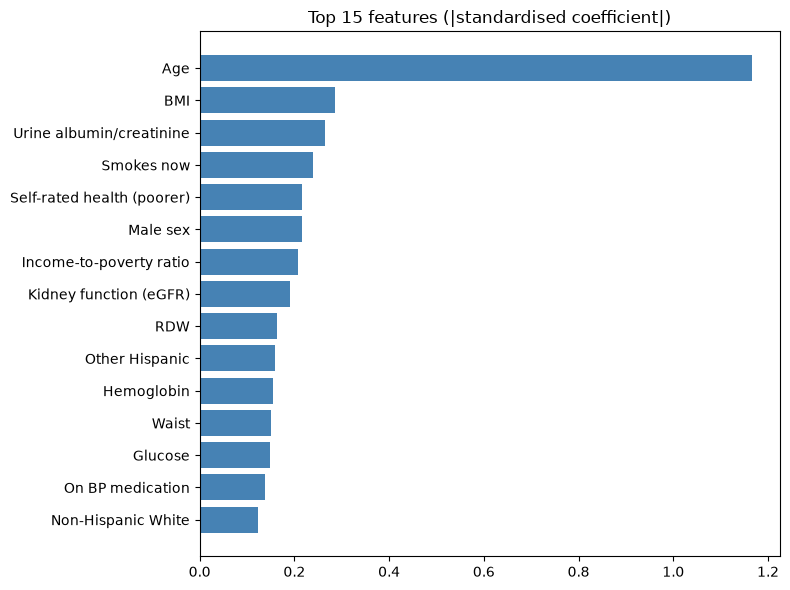

saved: cvd_pipeline.joblib, diagnostic.png, feature_importance.png, feature_schema.json, metrics_ml.json, nhanes_mortality_1999_2008.csv


In [13]:
top = coef.abs().sort_values().tail(15)
plt.figure(figsize=(8, 6)); plt.barh([FEATURE_LABELS.get(n, n) for n in top.index], top.values, color="steelblue")
plt.title("Top 15 features (|standardised coefficient|)"); plt.tight_layout(); plt.savefig(OUT_DIR / "feature_importance.png", dpi=150); plt.show()
reference = {c: float(X_train[c].median()) for c in RAW_NUMERIC_COLUMNS if X_train[c].notna().any()}
reference.update({c: float(X_train[c].mode().iloc[0]) for c in RAW_CODED_COLUMNS if X_train[c].notna().any()})
schema = {
    "model_name": metrics["model_name"], "model_version": metrics["model_version"],
    "raw_columns": RAW_COLUMNS, "numeric_columns": RAW_NUMERIC_COLUMNS, "coded_columns": RAW_CODED_COLUMNS,
    "reference_values": {k: round(v, 4) for k, v in reference.items()},
    "labels": {c: LABELS[c] for c in RAW_COLUMNS}, "decision_threshold": BANDS["low_max"],
}
joblib.dump(final, OUT_DIR / "cvd_pipeline.joblib", compress=3)
(OUT_DIR / "feature_schema.json").write_text(json.dumps(schema, indent=2) + "\n")
(OUT_DIR / "metrics_ml.json").write_text(json.dumps(metrics, indent=2) + "\n")
print("saved:", ", ".join(sorted(p.name for p in OUT_DIR.iterdir())))